[2026-07-18 16:09:52] [info     ] 计算右侧趋势启动因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-18 16:10:48] [info     ] 因子形状: (242000, 3)
        date instrument  factor
0 2024-01-02  000006.SZ    20.0
1 2024-01-02  000012.SZ    50.0
2 2024-01-02  000016.SZ    40.0
3 2024-01-02  000019.SZ    50.0
4 2024-01-02  000025.SZ     0.0
count    242000.000000
mean         18.839296
std          26.587652
min           0.000000
25%           0.000000
50%           0.600000
75%          40.000000
max          99.000000
Name: factor, dtype: float64
[2026-07-18 16:10:48] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-18 16:10:51] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-18 16:11:00] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-18 16:11:00] [info     ] ========== 数据检查 ==========
[2026-07-18 16:11:00] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_rat

时段,IC
2024-01-15~2024-02-08,-0.0014
2024-09-24~2024-10-08,-0.0358

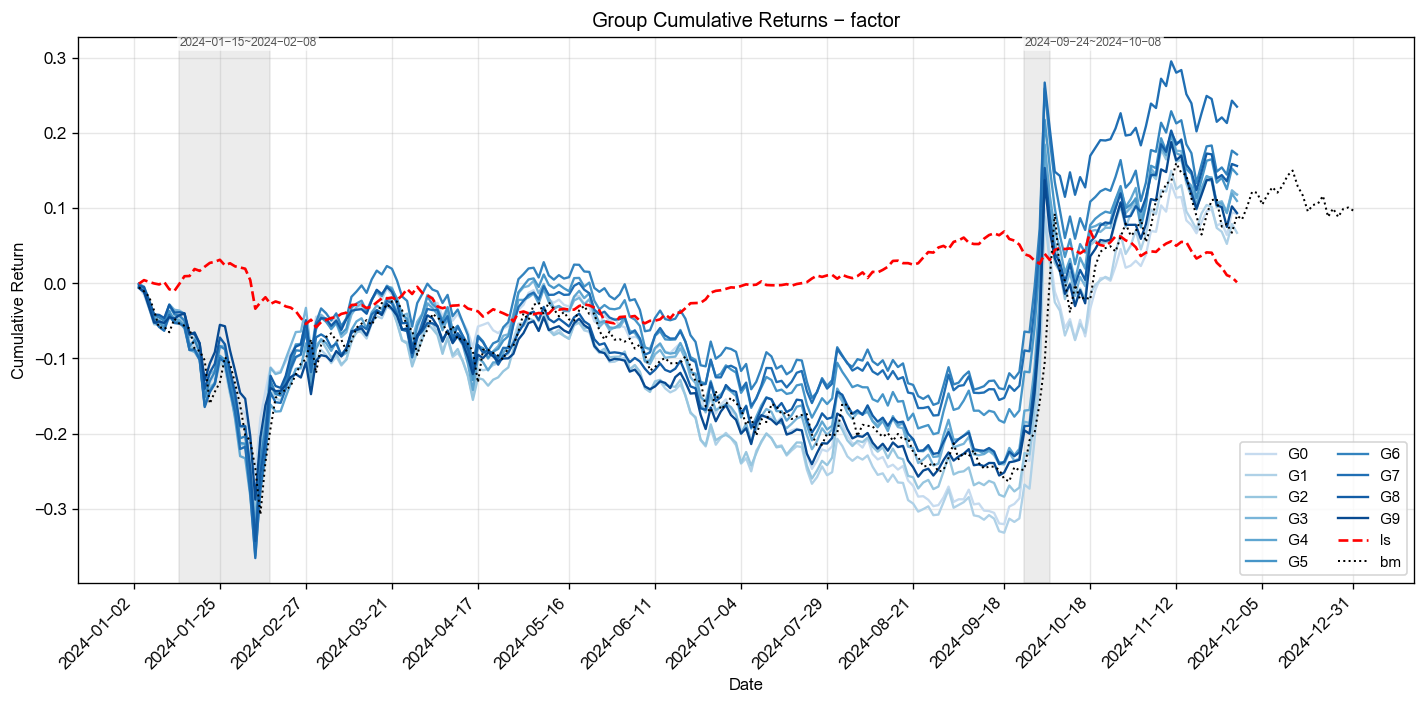
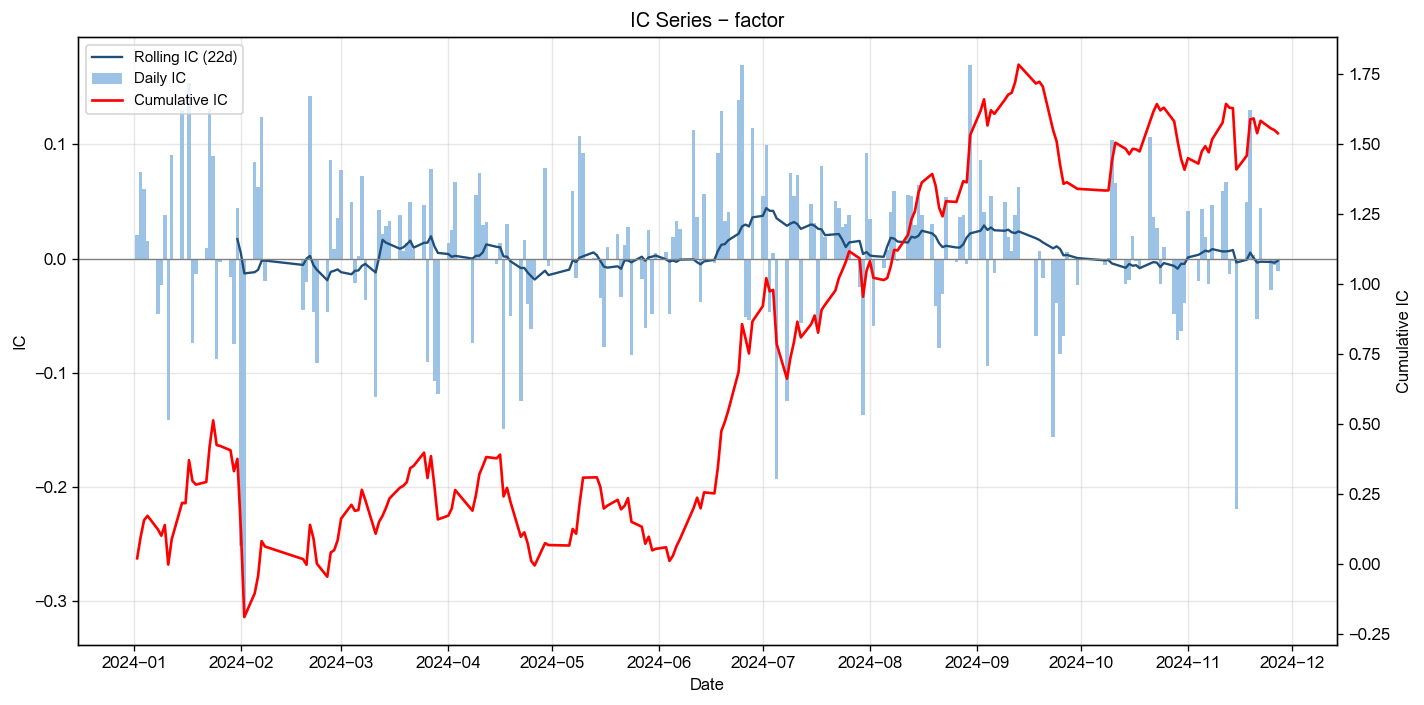
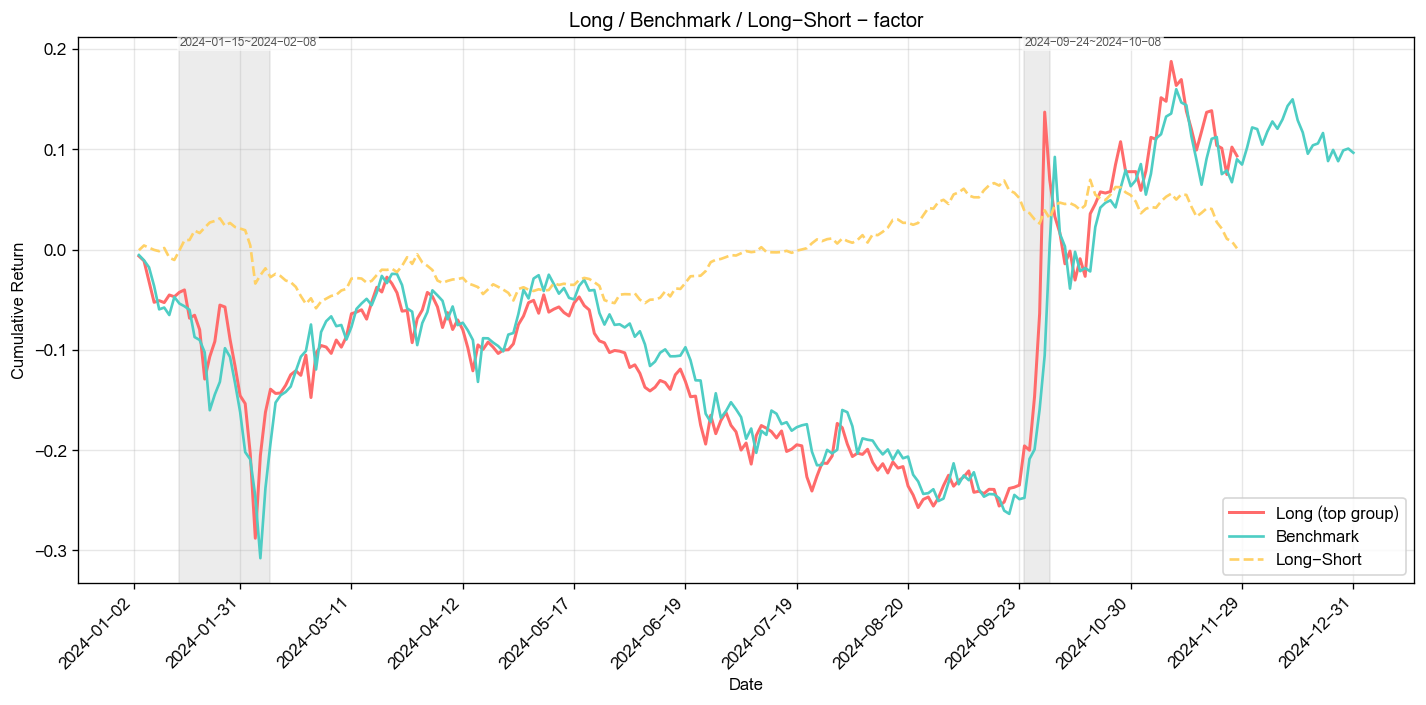
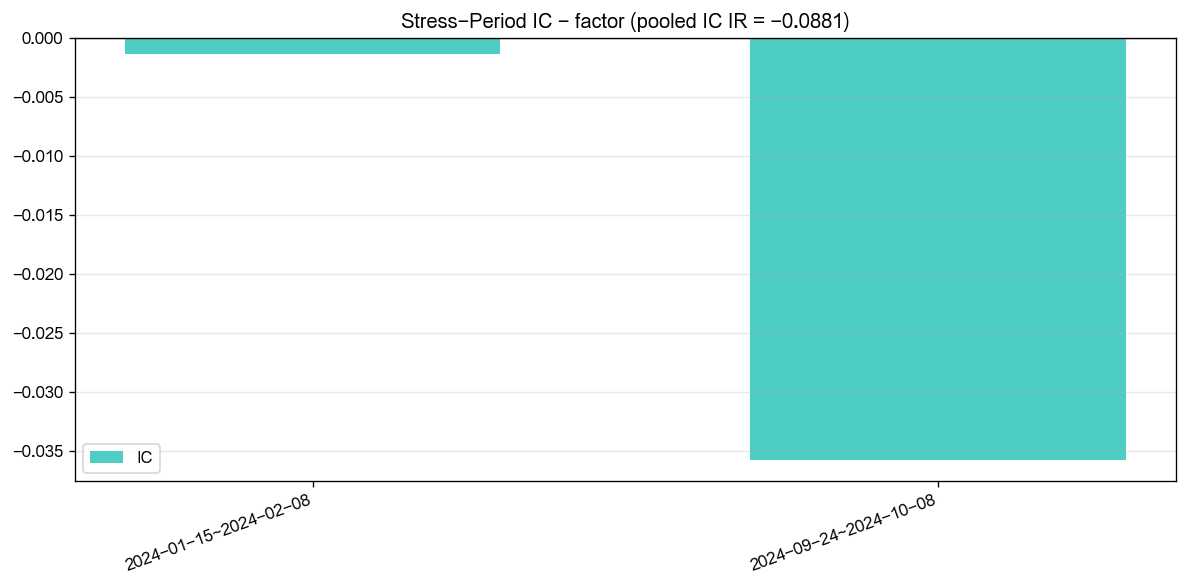
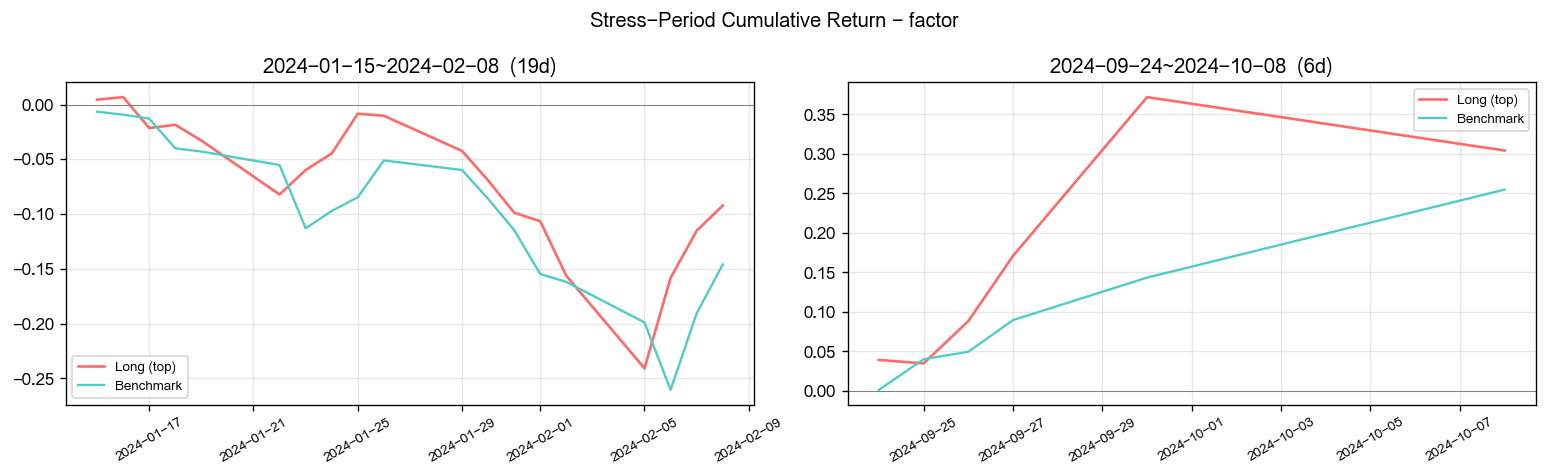

[2026-07-18 16:20:52] [info     ] ========== 因子池回归 ==========
[2026-07-18 16:20:53] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-18 16:20:53] [info     ] 获取收益率数据, 耗时: 1.022 秒
[2026-07-18 16:20:56] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.8444 秒
[2026-07-18 16:20:56] [info     ] 统计 回归结果, 耗时: 0.0121 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.7351,0.0444,0.0256,1.0000
2,amount,1.7127,0.0183,0.0107,0.9000
3,netflow_amount_rate_main,1.5455,0.0100,0.0064,1.0000
4,netflow_amount_main,1.5453,0.0256,0.0166,1.0000
5,gross_profit_rate_ttm,1.4948,0.0070,0.0047,1.0000
6,net_profit_rate_ttm,1.4616,0.0040,0.0027,0.8000
7,cci_14,1.4507,0.0341,0.0235,1.0000
8,pb,1.4160,0.0096,0.0068,1.0000
9,pe_ttm,1.3255,0.0029,0.0022,0.9000
10,ps_ttm,1.3058,0.0035,0.0027,0.9000

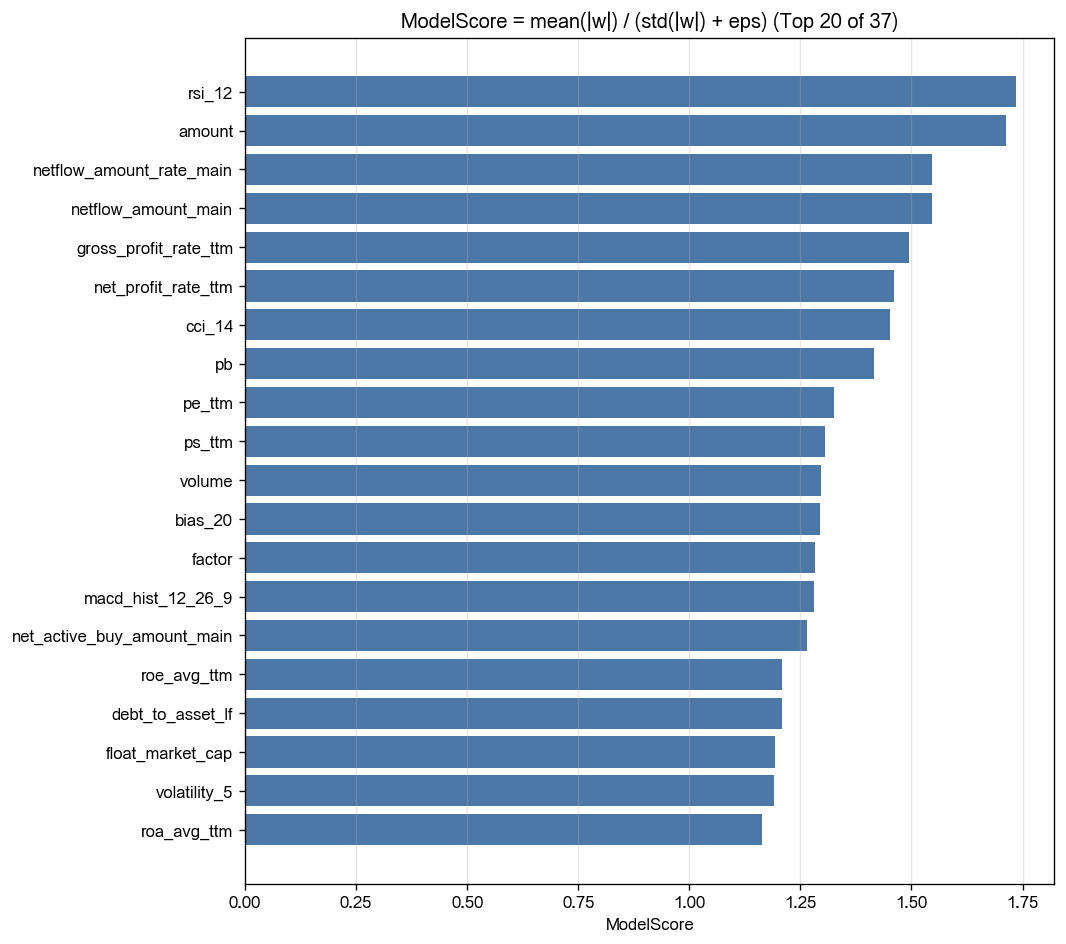
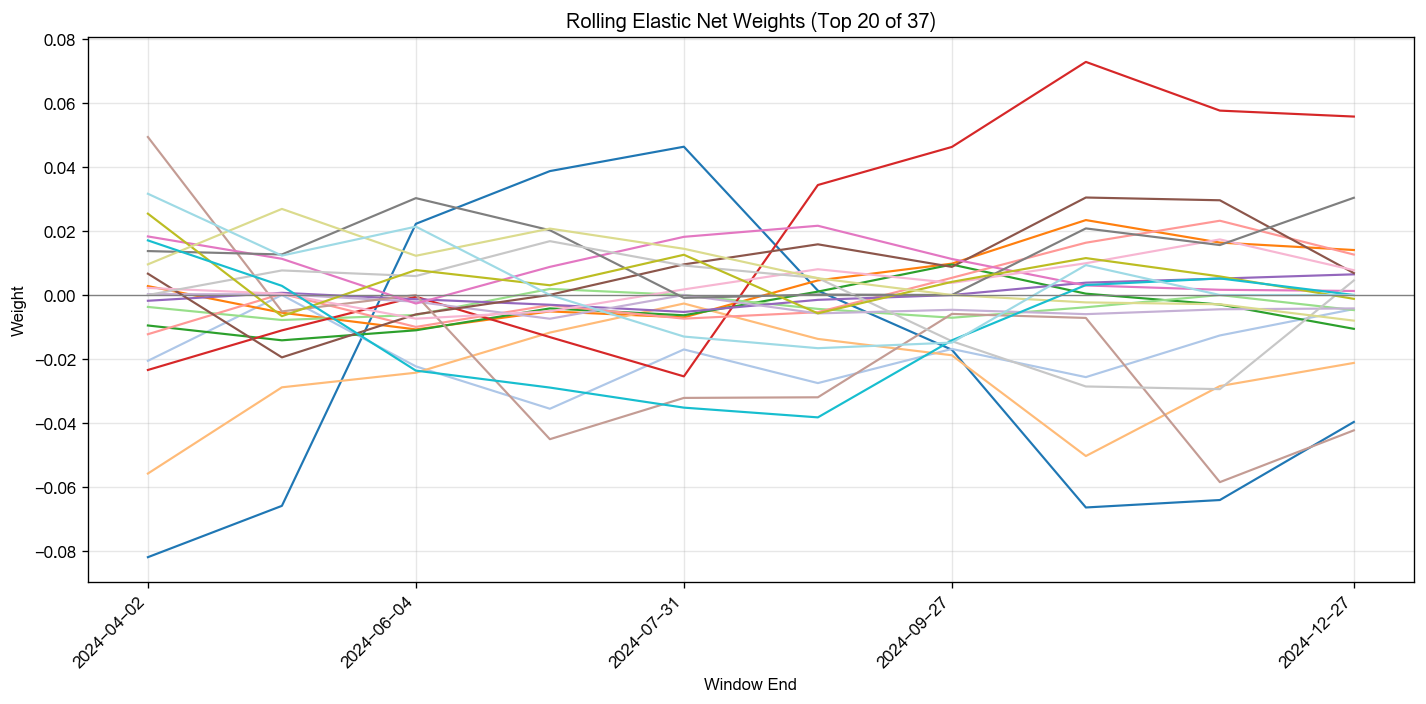
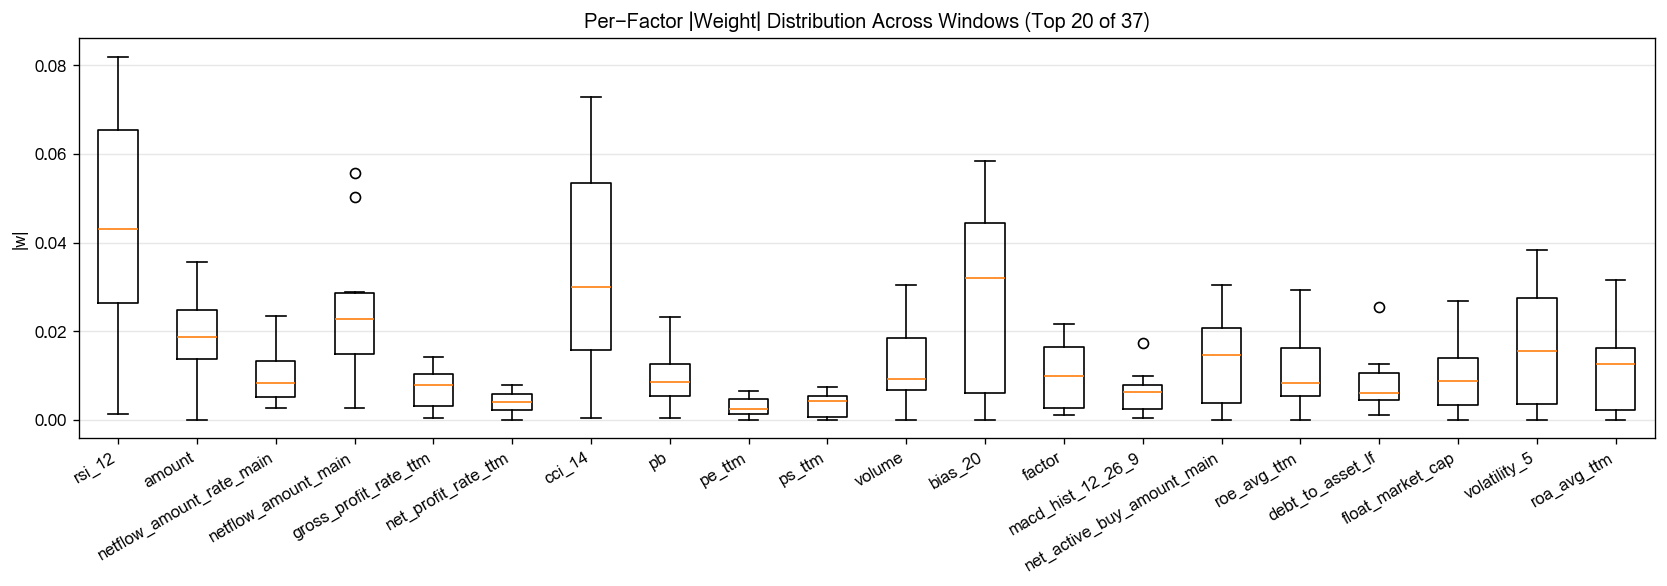
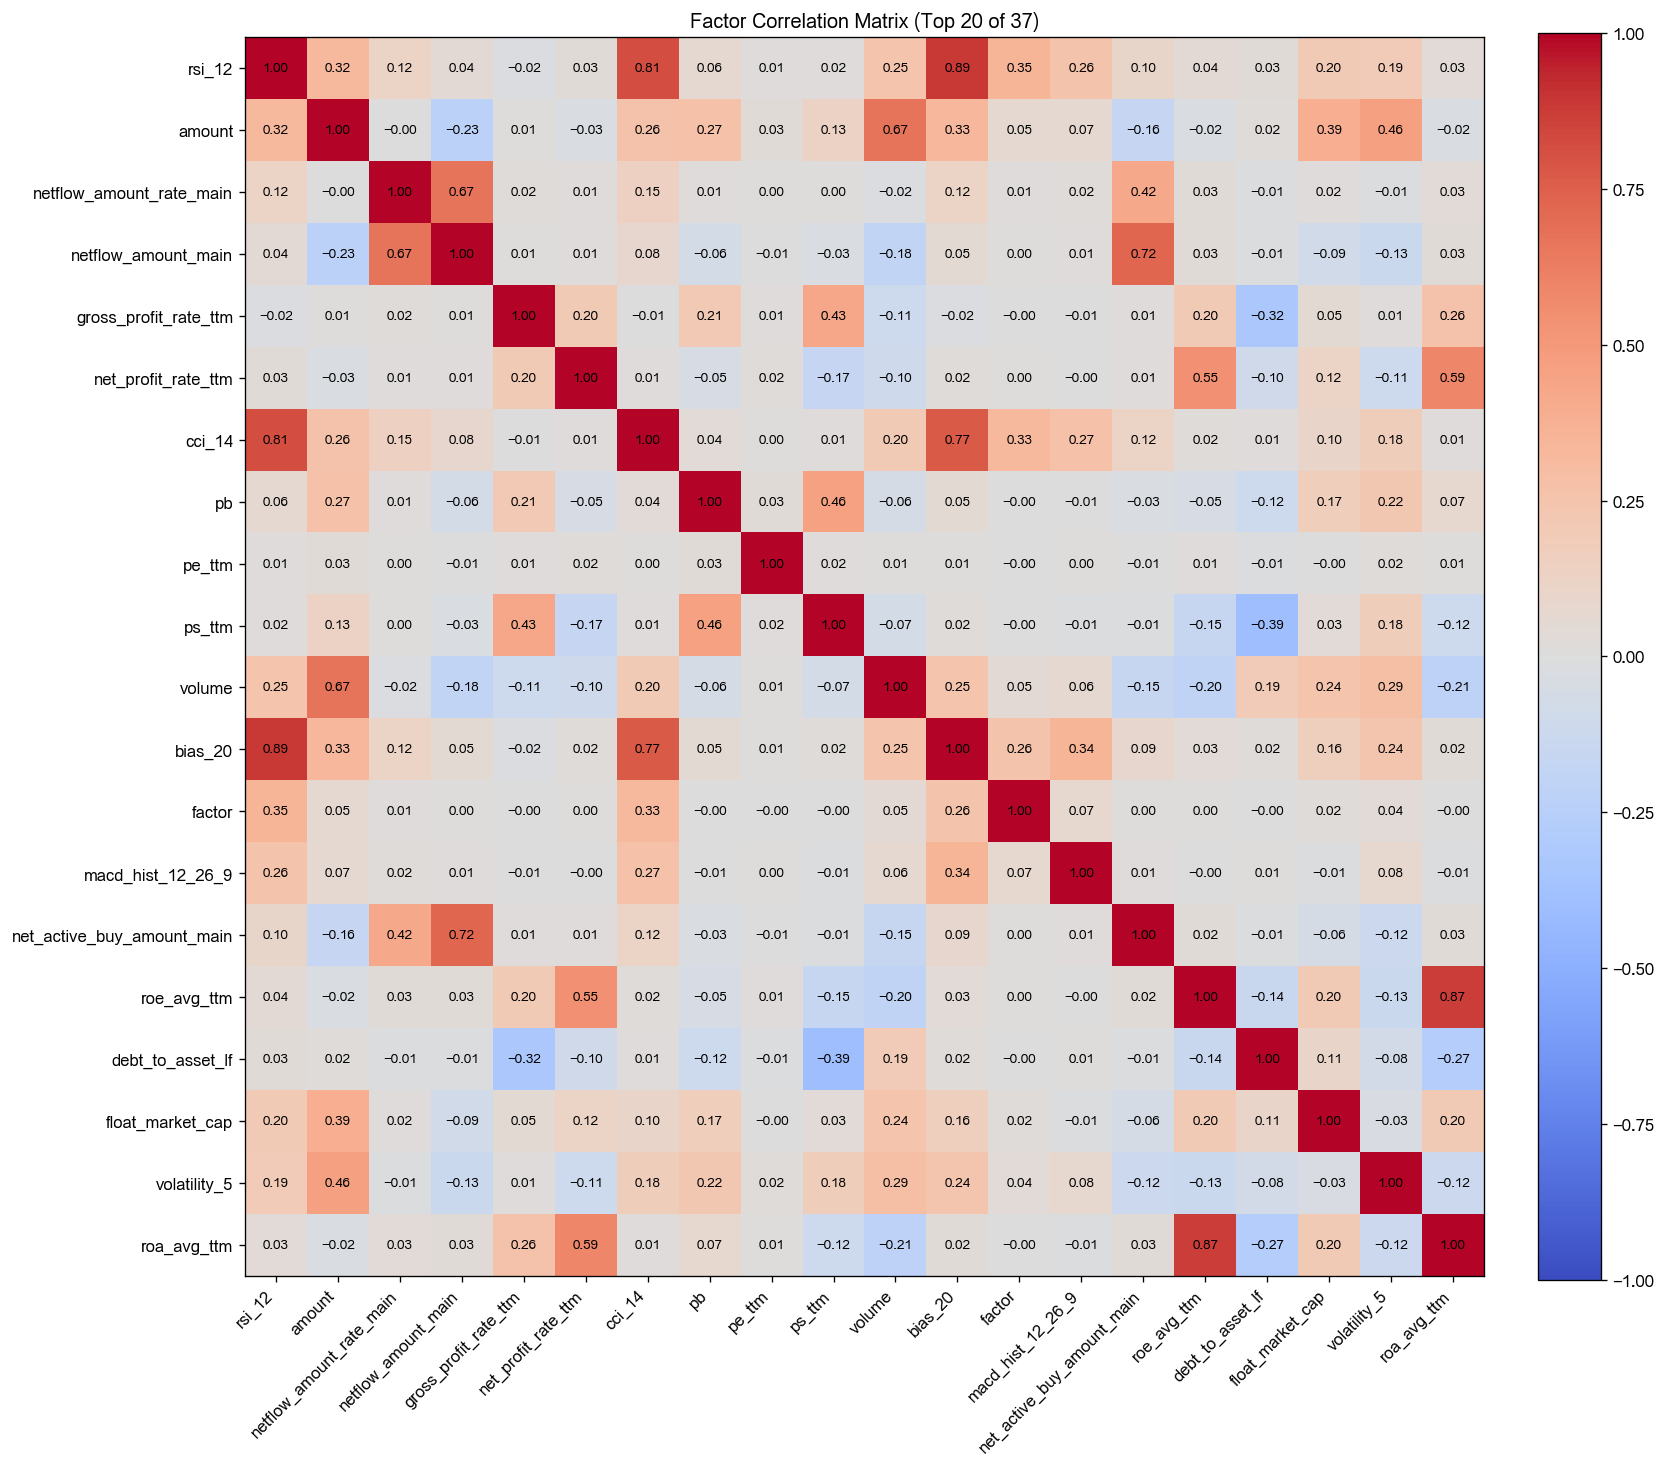

[2026-07-18 16:20:59] [warning  ] 返回的Outputs实例(size=33199960) 大于 64K, 将不会被缓存
[2026-07-18 16:20:59] [info     ] bigalpha_eval.v4 运行完成 [608.161s].


In [2]:
import pandas as pd
import numpy as np
import dai


def main(datasources, start_date, end_date):
    """
    ============================================================
    因子名称：右侧趋势启动选股因子 (Trend Initiation Scoring Factor)
    赛道：传统量化赛道
    
    【经济逻辑与核心思想】
    通过9项技术条件综合打分，筛选处于"右侧趋势启动"阶段的股票。
    核心理念：多重条件共振确认趋势，前置过滤排除异常信号，
    只在最健康的趋势启动点做多。
    
    【因子构建步骤】
    Step 1 - 日线聚合：从分钟数据聚合日线 OHLCV
    Step 2 - 技术指标计算：MA/MACD/RSI/乖离率等
    Step 3 - 9项条件打分：每满足一条得1分，满分9分
    Step 4 - 前置过滤：排除短期涨幅过大、异常放量、上涨乏力等
    Step 5 - 强度加分：满分票根据涨幅/量比等额外加分
    
    【统计方法】
    - 均线：20日/60日简单移动平均
    - MACD：EMA12-EMA26，DIF>0为多头
    - RSI：14日相对强弱，55~65为健康强势
    - 乖离率：(收盘价-60日均线)/60日均线，0~12%为温和上涨
    - 周线确认：过去25个交易日价格均值作为5周均线近似
    
    参数:
        datasources (dict): 数据源映射 {"bar1m": 物理表名}
        start_date (str): 测试集开始时间（平台注入）
        end_date (str):   测试集结束时间（平台注入）
    
    返回:
        pd.DataFrame: 三列 ['date', 'instrument', 'factor']，无 inf
    ============================================================
    """
    bar1m = datasources["bar1m"]

    LOOKBACK_DAYS = 90
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime('%Y-%m-%d %H:%M:%S')

    # ============================================================
    # [Step 1] 从分钟数据聚合日线 OHLCV
    # ============================================================
    sql = f"""
    WITH daily_bar AS (
        SELECT
            CAST(date::DATE AS DATETIME) AS date,
            instrument,
            FIRST(open ORDER BY date)   AS open,
            MAX(high)                   AS high,
            MIN(low)                    AS low,
            LAST(close ORDER BY date)   AS close,
            SUM(volume)                 AS volume,
            SUM(amount)                 AS amount
        FROM {bar1m}
        WHERE close > 0
        GROUP BY date::DATE, instrument
    )
    SELECT *
    FROM daily_bar
    """
    df = dai.query(sql, filters={'date': [query_start, end_date]}, compression=True).df()
    if df.empty:
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ============================================================
    # [Step 2-5] 按股票分组
    # ============================================================
    def process_group(stock_df):
        stock_df = stock_df.sort_values('date').reset_index(drop=True)
        n = len(stock_df)

        if n < 65:
            stock_df['factor'] = 0.0
            return stock_df

        close_raw = stock_df['close'].astype(float)
        high_raw = stock_df['high'].astype(float)
        low_raw = stock_df['low'].astype(float)
        open_raw = stock_df['open'].astype(float)
        volume_raw = stock_df['volume'].astype(float)

        # 全部使用前一天数据 (shift 1)
        close = close_raw.shift(1)
        high = high_raw.shift(1)
        low = low_raw.shift(1)
        open_ = open_raw.shift(1)
        volume = volume_raw.shift(1)

        # ---- 基础技术指标 ----
        ma20 = close.rolling(20, min_periods=1).mean()
        ma60 = close.rolling(60, min_periods=1).mean()
        ma5v = volume.rolling(5, min_periods=1).mean()

        ema12 = close.ewm(span=12, adjust=False).mean()
        ema26 = close.ewm(span=26, adjust=False).mean()
        dif = ema12 - ema26

        delta = close.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(14, min_periods=1).mean()
        avg_loss = loss.rolling(14, min_periods=1).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        rsi = 100 - (100 / (1 + rs))

        slope = (ma20 - ma20.shift(5)) / ma20.shift(5).replace(0, np.nan)
        bias = (close - ma60) / ma60.replace(0, np.nan)

        above_ma20 = close > ma20
        cond_above_3 = (
            above_ma20.shift(1).fillna(False) &
            above_ma20.shift(2).fillna(False) &
            above_ma20.shift(3).fillna(False)
        )

        weekly_ma5_approx = close.rolling(25, min_periods=1).mean()
        cond_weekly = close > weekly_ma5_approx

        # ---- 9项条件打分 ----
        # 用 float 确保连续，避免全0
        score = pd.Series(0.0, index=stock_df.index, dtype=float)

        # 每项满足=1，不满足=0
        c1 = (close > ma20).fillna(False).astype(float)
        c2 = (ma20 > ma60).fillna(False).astype(float)
        c3 = (volume >= ma5v * 1.5).fillna(False).astype(float)
        c4 = (dif > 0).fillna(False).astype(float)
        c5 = ((rsi >= 55) & (rsi <= 65)).fillna(False).astype(float)
        c6 = (slope > 0).fillna(False).astype(float)
        c7 = ((bias >= 0) & (bias <= 0.12)).fillna(False).astype(float)
        c8 = cond_above_3.fillna(False).astype(float)
        c9 = cond_weekly.fillna(False).astype(float)

        score = c1 + c2 + c3 + c4 + c5 + c6 + c7 + c8 + c9

        # ---- 前置过滤 ----
        ret_20d = close.pct_change(20)
        ret_5d = close.pct_change(5)
        vol_ratio = volume / ma5v.replace(0, np.nan)
        ret_high = high / close.shift(1) - 1
        body_ret = (close - open_) / open_.replace(0, np.nan)

        shadow_cond = (ret_high > 0.04) & (body_ret < 0.02)

        upper_shadow = (high - close) / close.replace(0, np.nan)
        is_yang = close > open_
        three_shadow_yang = (
            (upper_shadow > 0.02) & is_yang
        ).rolling(3, min_periods=1).apply(lambda x: x.all(), raw=True).fillna(0).astype(bool)

        ret_3d = close.pct_change(3)

        valid = (
            (ret_20d <= 0.25).fillna(True) &
            (ret_5d <= 0.15).fillna(True) &
            (vol_ratio <= 3.0).fillna(True) &
            (~shadow_cond).fillna(True) &
            (ret_3d > -0.02).fillna(True) &
            (~three_shadow_yang).fillna(True)
        )

        # 过滤后：不满足valid的分数降为0，但保留原始条件数作为基础分
        # 关键修复：即使过滤掉了，也用原始score/10作为基础分（0~0.9），确保没有全0天
        base_score = score / 10.0  # 0.0 ~ 0.9
        filtered_score = score.where(valid, 0.0)

        # ---- 强度加分 ----
        strength = pd.Series(0.0, index=stock_df.index, dtype=float)
        is_full = (filtered_score == 9.0)

        ret5_pct = ret_5d * 100
        strength += np.select(
            [is_full & (ret5_pct > 5), is_full & (ret5_pct > 3)],
            [2.0, 1.0], default=0.0
        )

        ret20_pct = ret_20d * 100
        strength += np.select(
            [is_full & (ret20_pct >= 5) & (ret20_pct <= 15),
             is_full & (ret20_pct < 5)],
            [2.0, 1.0], default=0.0
        )

        bias_pct = bias * 100
        strength += np.select(
            [is_full & (bias_pct >= 2) & (bias_pct <= 5),
             is_full & (bias_pct >= 0) & (bias_pct < 2)],
            [2.0, 1.0], default=0.0
        )

        vr = vol_ratio
        strength += np.select(
            [is_full & (vr >= 1.5) & (vr <= 3),
             is_full & (vr > 5)],
            [2.0, -1.0], default=0.0
        )

        max_abs_ret = pd.concat([
            abs(close / close.shift(1) - 1),
            abs(close.shift(1) / close.shift(2) - 1),
            abs(close.shift(2) / close.shift(3) - 1)
        ], axis=1).max(axis=1)
        strength += np.where(is_full & (max_abs_ret < 0.05), 1.0, 0.0)

        # ---- 最终因子 ----
        # 修复：未被过滤的 = 满分(90) + 强度分；被过滤的 = 基础分(0~0.9)确保非零区分度
        final_factor = np.where(
            valid,
            filtered_score * 10.0 + strength,  # 0~99
            base_score  # 0~0.9，确保不为零
        )
        stock_df['factor'] = final_factor.astype(float)

        return stock_df

    df = df.groupby('instrument', group_keys=False).apply(process_group)

    # ---- 过滤到目标区间 ----
    start_dt = pd.to_datetime(start_date)
    df = df[df['date'] >= start_dt].copy()

    # ---- 对齐中证1000成分股 ----
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
        compression=True
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    df['instrument'] = df['instrument'].astype(str)

    final_df = pd.merge(
        stk_pool,
        df[['date', 'instrument', 'factor']],
        how='left',
        on=['date', 'instrument']
    )

    # ---- 填充缺失值 ----
    # 如果某只股票完全没有数据（停牌等），给一个极小随机值确保非零区分度
    final_df['factor'] = final_df['factor'].fillna(0.0)
    final_df['factor'] = final_df['factor'].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return final_df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算右侧趋势启动因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"因子形状: {factor_data.shape}")
    print(factor_data.head())
    print(factor_data['factor'].describe())

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )